[INFO] Simulating database data extraction for a single sensor...

--- Raw Unfiltered Head DataFrame Snapshot ---
            timestamp      device_id  temperature  humidity pressure_hpa  \
0 2015-02-02 18:00:00  arduino_dht22        23.15     46.75         None   
1 2015-02-02 18:00:05  arduino_dht22        22.96     47.68         None   
2 2015-02-02 18:00:10  arduino_dht22        23.19     47.19         None   
3 2015-02-02 18:00:15  arduino_dht22        23.46     46.37         None   
4 2015-02-02 18:00:20  arduino_dht22        22.93     46.48         None   
5 2015-02-02 18:00:25  arduino_dht22        22.93     45.70         None   

  status  
0     OK  
1     OK  
2     OK  
3     OK  
4     OK  
5     OK  

[METRIC] Arduino DHT22 Mean Temperature: 23.00°C
[METRIC] Arduino DHT22 Mean Humidity: 46.49%

[VISUALIZE] Launching plotting viewport...


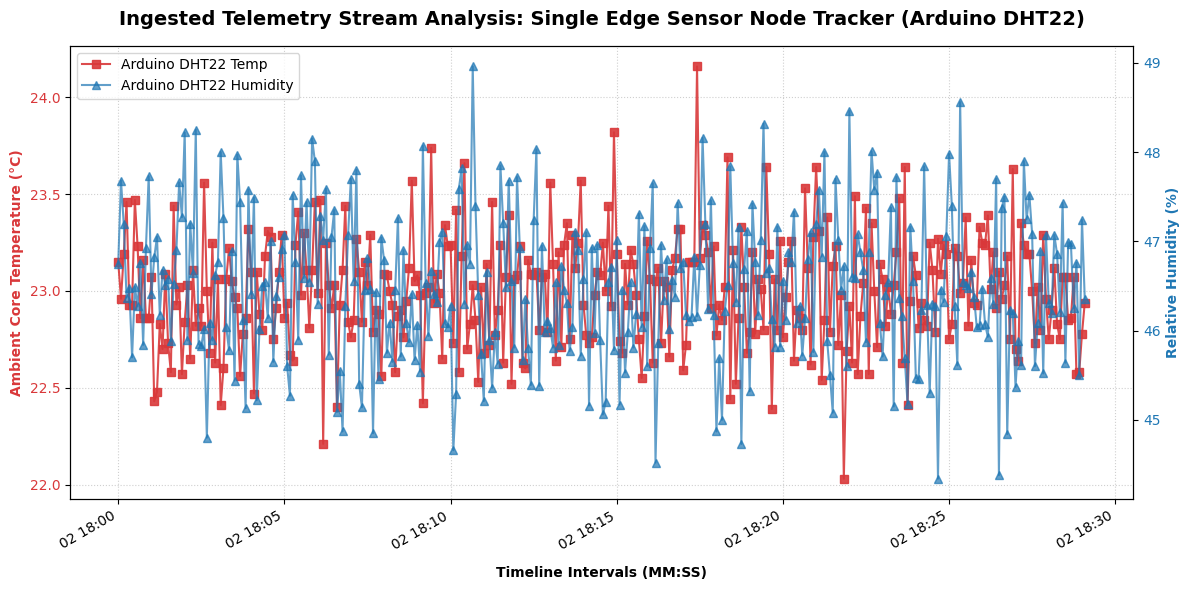

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ==============================================================================
# 1. DATA GENERATION (Simulating Database Extraction via NumPy)
# ==============================================================================
print("[INFO] Simulating database data extraction for a single sensor...")
np.random.seed(42)  # Seeds random numbers for consistent results across runs
sample_size = 350 # Total samples for the single sensor

# Build a linear progression of mock database timestamps
base_time = datetime(2015, 2, 2, 18, 0, 0)
time_vector = [base_time + timedelta(seconds=i*5) for i in range(sample_size)]

# Generate device telemetry readings using localized random normal distributions for Arduino DHT22
arduino_temp = np.random.normal(loc=23.0, scale=0.3, size=sample_size)
arduino_humid = np.random.normal(loc=46.5, scale=0.8, size=sample_size)

# ==============================================================================
# 2. DATA FRAME CONSTRUCTION & WRAPPING (Pandas Pipeline)
# ==============================================================================
# Create records for a single sensor (Arduino DHT22)
records = []
for i in range(sample_size):
    records.append({
        "timestamp": time_vector[i],
        "device_id": "arduino_dht22",
        "temperature": round(arduino_temp[i], 2),
        "humidity": round(arduino_humid[i], 2),
        "pressure_hpa": None, # DHT22 does not measure pressure
        "status": "OK"
    })

# Convert raw records list to a structured Pandas DataFrame
df = pd.DataFrame(records)

print("\n--- Raw Unfiltered Head DataFrame Snapshot ---")
print(df.head(6))

# The DataFrame now directly represents the single sensor's data
sensor_df = df.dropna(axis=1, how='all')

# Calculate high-level aggregates using native Pandas math operators
print(f"\n[METRIC] Arduino DHT22 Mean Temperature: {sensor_df['temperature'].mean():.2f}°C")
print(f"[METRIC] Arduino DHT22 Mean Humidity: {sensor_df['humidity'].mean():.2f}%")

# ==============================================================================
# 3. GRAPHICAL RENDERING (Matplotlib Engine)
# ==============================================================================
print("\n[VISUALIZE] Launching plotting viewport...")

# Instantiate a multi-axis chart structure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Layer A: Primary Y-Axis (Temperature Trends)
color_temp = '#d9383a'
ax1.set_xlabel('Timeline Intervals (MM:SS)', fontweight='bold', labelpad=10)
ax1.set_ylabel('Ambient Core Temperature (°C)', color=color_temp, fontweight='bold')

# Plot line metrics for the single hardware configuration (Arduino DHT22 Temperature)
ax1.plot(sensor_df['timestamp'], sensor_df['temperature'], color=color_temp,
         linestyle='-', marker='s', alpha=0.9, label='Arduino DHT22 Temp')
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot Layer B: Secondary Y-Axis sharing the exact same X-Axis footprint (Humidity Trends)
ax2 = ax1.twinx()
color_humid = '#1f77b4'
ax2.set_ylabel('Relative Humidity (%)', color=color_humid, fontweight='bold')

# Plot humidity line metrics
ax2.plot(sensor_df['timestamp'], sensor_df['humidity'], color=color_humid,
         linestyle='-', marker='^', alpha=0.7, label='Arduino DHT22 Humidity')
ax2.tick_params(axis='y', labelcolor=color_humid)

# Layout adjustments and clean date labels formatting
fig.autofmt_xdate()
plt.title('Ingested Telemetry Stream Analysis: Single Edge Sensor Node Tracker (Arduino DHT22)',
          fontsize=14, fontweight='bold', pad=15)

# Gather and overlay composite legend panels from both coordinate engines
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [5]:
print("[INFO] Loading data ")
occupancy_df = pd.read_csv('/content/Occupancy.csv')
display(occupancy_df.head())
display(occupancy_df.info())

[INFO] Loading data 


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,1
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20560 entries, 0 to 20559
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           20560 non-null  object 
 1   Temperature    20560 non-null  float64
 2   Humidity       20560 non-null  float64
 3   Light          20560 non-null  float64
 4   CO2            20560 non-null  float64
 5   HumidityRatio  20560 non-null  float64
 6   Occupancy      20560 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 1.1+ MB


None

[INFO] Preparing data for visualization...

[VISUALIZE] Plotting sensor data and occupancy...


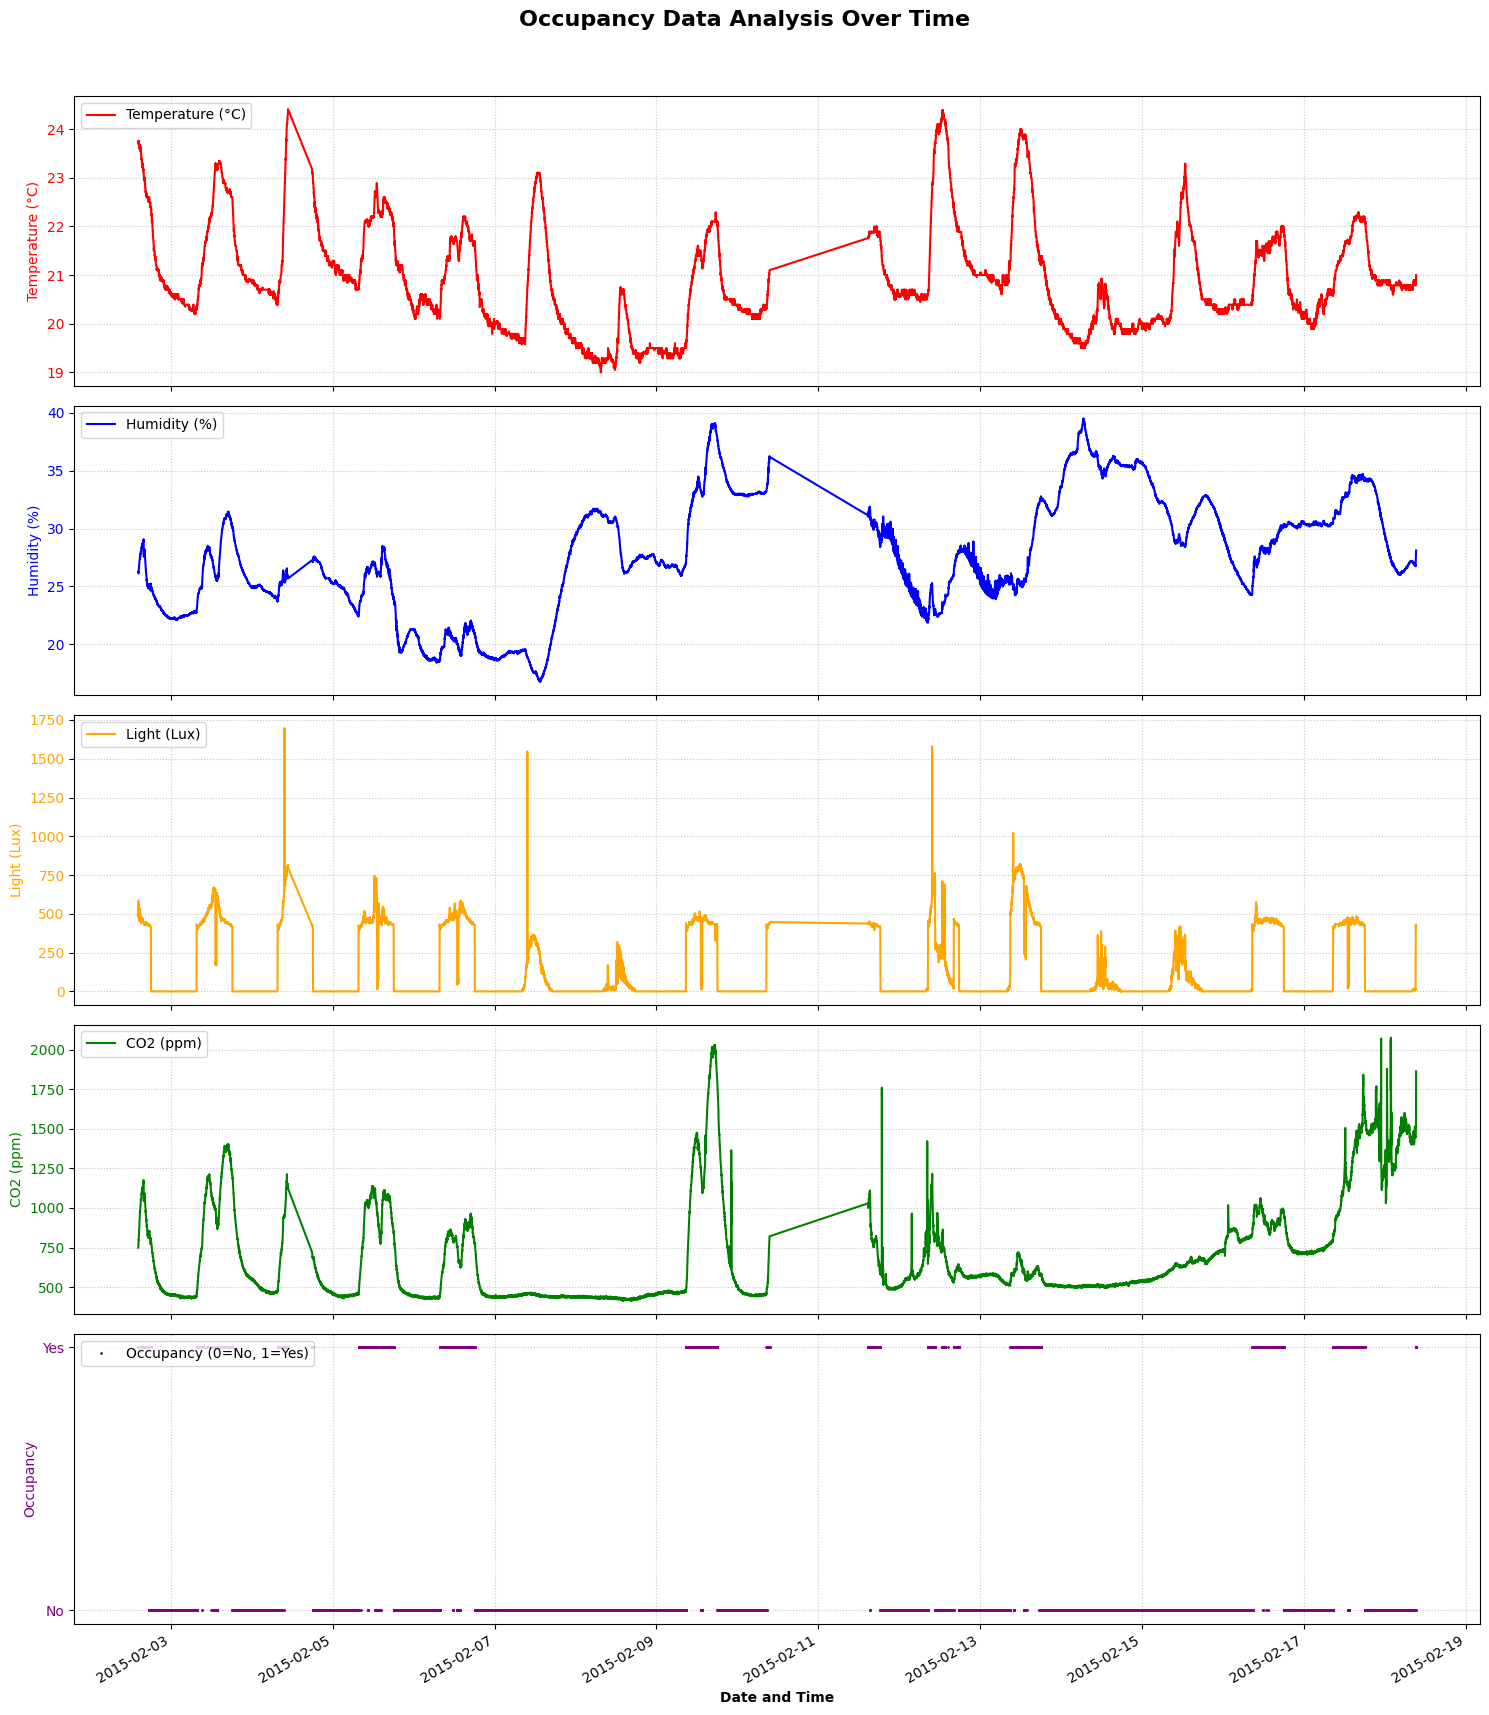

In [6]:
print("[INFO] Preparing data for visualization...")
# Convert 'date' column to datetime objects
occupancy_df['date'] = pd.to_datetime(occupancy_df['date'])

# Set 'date' as index for time series plotting
occupancy_df.set_index('date', inplace=True)

print("\n[VISUALIZE] Plotting sensor data and occupancy...")

# Create a multi-panel plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 18), sharex=True)
fig.suptitle('Occupancy Data Analysis Over Time', fontsize=16, fontweight='bold')

# Plot Temperature
axes[0].plot(occupancy_df.index, occupancy_df['Temperature'], color='red', label='Temperature (°C)')
axes[0].set_ylabel('Temperature (°C)', color='red')
axes[0].tick_params(axis='y', labelcolor='red')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='upper left')

# Plot Humidity
axes[1].plot(occupancy_df.index, occupancy_df['Humidity'], color='blue', label='Humidity (%)')
axes[1].set_ylabel('Humidity (%)', color='blue')
axes[1].tick_params(axis='y', labelcolor='blue')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper left')

# Plot Light
axes[2].plot(occupancy_df.index, occupancy_df['Light'], color='orange', label='Light (Lux)')
axes[2].set_ylabel('Light (Lux)', color='orange')
axes[2].tick_params(axis='y', labelcolor='orange')
axes[2].grid(True, linestyle=':', alpha=0.7)
axes[2].legend(loc='upper left')

# Plot CO2
axes[3].plot(occupancy_df.index, occupancy_df['CO2'], color='green', label='CO2 (ppm)')
axes[3].set_ylabel('CO2 (ppm)', color='green')
axes[3].tick_params(axis='y', labelcolor='green')
axes[3].grid(True, linestyle=':', alpha=0.7)
axes[3].legend(loc='upper left')

# Plot Occupancy
# Using a scatter plot for binary data or shading to show occupied periods
# Here, we'll use a line plot for simplicity, but could be enhanced.
axes[4].plot(occupancy_df.index, occupancy_df['Occupancy'], color='purple', label='Occupancy (0=No, 1=Yes)', linestyle='None', marker='.', markersize=2)
axes[4].set_ylabel('Occupancy', color='purple')
axes[4].tick_params(axis='y', labelcolor='purple')
axes[4].set_yticks([0, 1])
axes[4].set_yticklabels(['No', 'Yes'])
axes[4].grid(True, linestyle=':', alpha=0.7)
axes[4].legend(loc='upper left')

# General plot adjustments
fig.autofmt_xdate()
plt.xlabel('Date and Time', fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()